# Assignment - Building a Travel & Flight Optimization App

## Welcome to TravelOptima Inc!

Congratulations! You've just been hired as a software engineer at TravelOptima Inc., a startup building the next-generation travel planning platform.

Your manager needs you to build the core algorithms for two critical features:
1. **Smart Flight Finder** - Find the cheapest flight routes between countries
2. **Tour Optimizer** - Find the shortest tour visiting multiple destinations

The good news? You can work with an LLM to implement these algorithms.

---

## Your Assignment

**Phase 1 (GRADED):** Build the core algorithms
- Exercise 1: `find_shortest_path` - Shortest path finder (Dijkstra's algorithm)
- Exercise 2: `optimize_world_tour` - Multi-destination tour optimizer (TSP with heuristics)

**Phase 2 (OPTIONAL - NOT GRADED):** Advanced features
- Exercise 3: Customize the web app UI (make it your own!)

---

## Technical Requirements

- **Only Exercises 1 & 2 are graded** - Focus on getting these right!
- Work with your LLM - ask questions, iterate, debug together
- Your functions must accept/return the correct JSON format
- Avoid importing new libraries (especially `joblib` - crashes the grader)
- Use an LLM of your choice ([GPT-4o available here](https://www.coursera.org/learn/introduction-to-generative-ai-for-software-development/ungradedLab/Vuqvf/gpt-3-5-environment))

**Need help?** Visit our [Discourse Community](https://www.coursera.org/learn/introduction-to-generative-ai-for-software-development/item/hIZen).

---


# Table of Contents
- [ 1 - The Challenge](#1)
  - [ 1.1 - Importing unittests](#1-1)
  - [ 1.2 - Graph Data Structure](#1-2)
- [ 2 - Recommended Workflow with Your LLM](#2)
- [ 3 - Playground](#3)
  - [ 3.1 - Graph Generation](#3-1)
- [ 4 - Your Assignments](#4)
  - [ Exercise 1](#ex01)
  - [ Exercise 2](#ex02)
  - [ Exercise 3](#ex03)


<a id='1'></a>

<a id='1'></a>
## 1 - The Challenge

### Email from Your Manager

```
From: Sarah Chen <sarah@traveloptima.com>
To: You (New Software Engineer)
Subject: First Assignment - Core Algorithms

Hi there!

Welcome to the team! We're building a travel optimization platform and 
need you to implement two critical algorithms:

1. SHORTEST PATH FINDER (Due: End of this week)
   - Users want the cheapest flight route between two countries
   - Sometimes connecting flights are cheaper than direct!
   - We need an algorithm to find the optimal route

2. TOUR OPTIMIZER (Due: End of this week)
   - Many customers want to visit multiple countries in one trip
   - They want to minimize total travel distance
   - This is the Traveling Salesman Problem - find the shortest tour
   - You'll test it on 15 countries across the Americas

The great thing? You can use any LLM to help you implement these.
Just make sure the functions work correctly - that's what matters.

Our UI team will integrate your algorithms into the web app! I'm sending there an app image so you can have an idea of how it looks like!


Good luck!
Sarah
```
#### Attached picture

<p align="center">
  <img src="images/app.png" width="60%">
</p>

---

**Your functions must:**
- Accept the graph data structure (section 1.3)
- Return the specified output format
- Produce correct results

**How you get there is up to you!**

<a id='1-1'></a>
### 1.1 - Importing unittests

This library includes unit tests to evaluate your solutions. After every exercise, there will be a cell with a unittest. Run it to get your solution tested.

There is also a submission checker, which you should run at the end of the assignment, to ensure that your solution will be properly evaluated by the autograder.

In [4]:
import unittests as unittests
from utils import (
    generate_graph_json,
    validate_graph_json,
    plot_graph_with_path,
    plot_continent_path,
    load_world_tour_graph,
    load_continents_graph,
    create_country_coords_for_plot,
    create_americas_tour_widget,
    launch_tour_widget
)

<a id='1-3'></a>

<a id='1-2'></a>
### 1.2 - Graph Data Structure

All graphs in this assignment use a **Python dictionary** with this structure:

```python
{
    "nodes": [0, 1, 2, 3, 4],
    "edges": [
        {"from": 0, "to": 1, "weight": 10},
        {"from": 1, "to": 3, "weight": 12},
        # ...
    ],
    "directed": False  # Optional, defaults to False
}
```

**Key points:**
- This is a regular Python dictionary (not a JSON string)
- `nodes`: List of node identifiers (can be integers, strings, etc.)
- `edges`: List of connections with weights (positive numbers)
- `directed`: If False, edges work both directions
- For undirected graphs, only one edge entry needed per connection

**Note:** We call this "JSON format" because it follows JSON structure, but in Python it's just a dict. You don't need to import the `json` library.

<a id='2'></a>

<a id='2'></a>
## 2 - Recommended Workflow with Your LLM

### How Professional Developers Use LLMs

You're not just learning algorithms - you're learning how to work with AI assistants to solve problems faster.

**Recommended approach:**

1. **Understand the problem** - Discuss with the LLM, clarify concepts
2. **Explore the data format** - Understand the JSON structure
3. **Brainstorm solutions** - Ask: "What algorithms can solve this?"
4. **Implement incrementally** - Start simple, test often
5. **Test on small examples** - Verify with 3-4 node graphs first
6. **Debug together** - Share error messages, get help
7. **Optimize** - Improve performance if needed

### Example LLM Prompts

**Good prompts:**
- "Explain Dijkstra's algorithm in simple terms"
- "Help me implement shortest path in Python without external libraries"
- "I'm getting this error: [paste error]. What's wrong?"
- "How can I optimize my TSP solution for 15 nodes?"

**Less effective prompts:**
- "Give me the code" (learn by understanding!)
- "Is this right?" (be specific about what concerns you)

---

<a id='3'></a>

<a id='3'></a>
## 3 - Playground

Use this section to test your code. The `generate_graph_json()` function creates test graphs.

**Note:** Only code in graded cells is evaluated. Feel free to create as many test cells as you need.

<a id='3-1'></a>

<a id='3-1'></a>
### 3.1 - Graph Generation

The `generate_graph_json()` function creates test graphs with various properties. This is also used in unit tests.

In [5]:
# Create a small complete graph
example_graph = generate_graph_json(num_nodes=6, complete=True, seed=123)
example_graph

{'nodes': [0, 1, 2, 3, 4, 5],
 'edges': [{'from': 0, 'to': 1, 'weight': 7},
  {'from': 0, 'to': 2, 'weight': 35},
  {'from': 0, 'to': 3, 'weight': 12},
  {'from': 0, 'to': 4, 'weight': 99},
  {'from': 0, 'to': 5, 'weight': 53},
  {'from': 1, 'to': 2, 'weight': 35},
  {'from': 1, 'to': 3, 'weight': 14},
  {'from': 1, 'to': 4, 'weight': 5},
  {'from': 1, 'to': 5, 'weight': 49},
  {'from': 2, 'to': 3, 'weight': 69},
  {'from': 2, 'to': 4, 'weight': 72},
  {'from': 2, 'to': 5, 'weight': 43},
  {'from': 3, 'to': 4, 'weight': 44},
  {'from': 3, 'to': 5, 'weight': 7},
  {'from': 4, 'to': 5, 'weight': 21}],
 'directed': False}

#### Graph Visualization

The `plot_graph_with_path()` function visualizes graphs. **Note:** 2D plots don't preserve distances.

Installing required libraries...


C:\Users\mahmi\Desktop\Coursera\DeepLearning.AI\Generative AI for Software Development\Jupyter Notebooks\Scripts\Assignments\TSP_Problem\utils.py:468: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


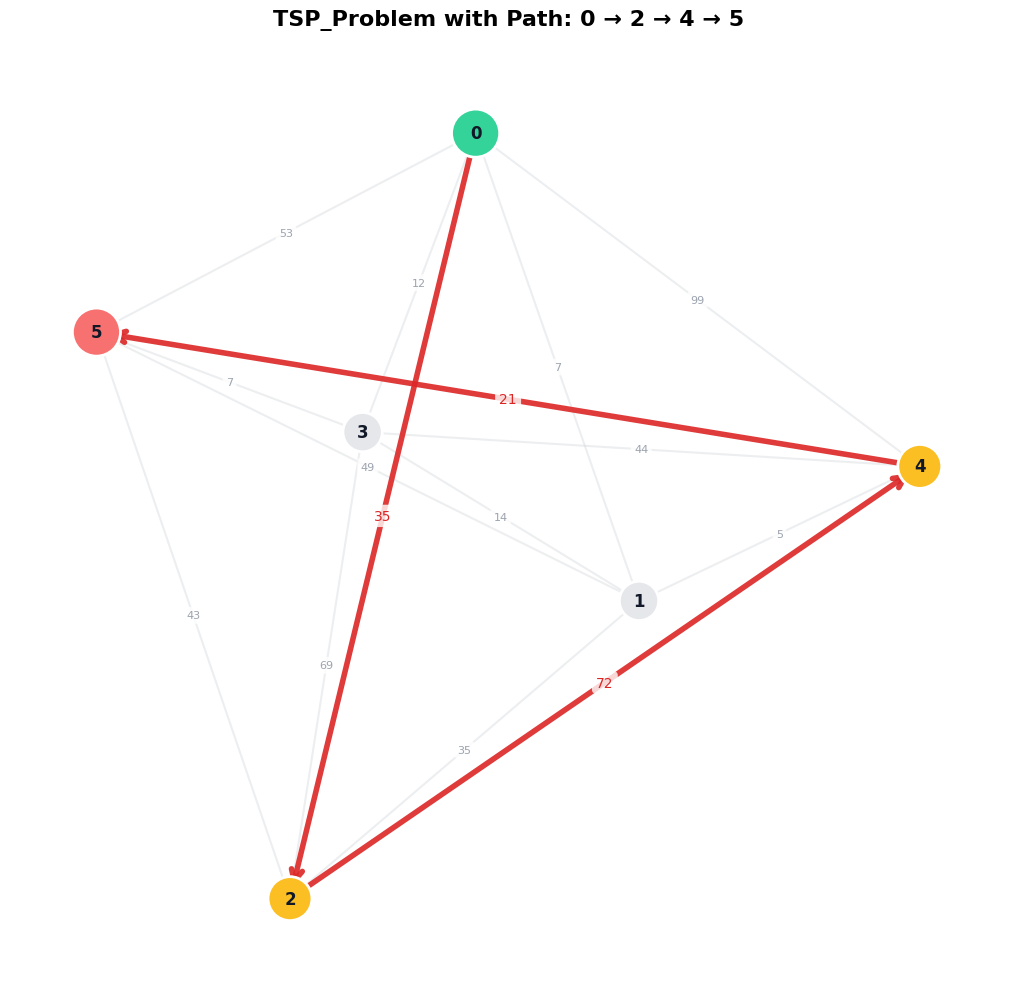


📍 Path Details:
  Step  1: Node 0 → Node 2  (weight:   35.0)
  Step  2: Node 2 → Node 4  (weight:   72.0)
  Step  3: Node 4 → Node 5  (weight:   21.0)
  Total Path Weight: 128.0
  Nodes Visited: 4
  Edges Traversed: 3



In [6]:
# Create a small complete graph
example_graph = generate_graph_json(num_nodes=6, complete=True, seed=123)

# Define a path through some nodes (these nodes should be connected in the graph)
example_path = [0, 2, 4, 5]

# Visualize the graph with the highlighted path
plot_graph_with_path(example_graph, example_path)

In [7]:
# Create a sparse graph
sparse_graph = generate_graph_json(num_nodes=10, num_edges_per_node=2, seed=42)

print("Sparse graph with 10 nodes, ~2 edges per node:")
print(f"Total edges: {len(sparse_graph['edges'])}")
print("\nFirst 5 edges:")
for edge in sparse_graph['edges'][:5]:
    print(f"  {edge['from']} -> {edge['to']}: weight {edge['weight']}")

Sparse graph with 10 nodes, ~2 edges per node:
Total edges: 20

First 5 edges:
  0 -> 1: weight 4
  0 -> 4: weight 32
  1 -> 3: weight 18
  1 -> 8: weight 12
  2 -> 9: weight 55


<a id='4'></a>

<a id='4'></a>
## 4 - Your Assignments

### Phase 1: Core Algorithms (GRADED)

These are **required** and will be graded:
- **Exercise 1:** `find_shortest_path` - Flight route finder
- **Exercise 2:** `optimize_world_tour` - Multi-destination tour optimizer

### Phase 2: Advanced Features (OPTIONAL - NOT GRADED)

Want extra practice or to impress your "manager"?
- **Exercise 3:** Customize the web app UI (see end of notebook)

**Remember:** Work with your LLM, understand the concepts, and implement incrementally!

---

<a id='ex01'></a>

<a id='ex01'></a>
### Exercise 1

**From Sarah:** *"Our users need to find the cheapest flight routes. Sometimes a connecting flight through a hub is cheaper than a direct flight! We need an algorithm that finds the optimal route."*

---

**Your Task:** Implement a shortest path algorithm (Dijkstra's works great!).

**Function Signature:**
```python
def find_shortest_path(graph_json, start_node, end_node):
    """
    Returns: list of nodes [start, ..., end], or [] if no path exists
    Example: [0, 2, 3, 4] for path 0→2→3→4
    """
```

**Requirements:**
- Find the minimum total weight path (cheapest route)
- Return path as list of nodes, or empty list if no path exists
- Must work for directed and undirected graphs

**Hints:**
- Dijkstra's algorithm is commonly used for weighted shortest paths
- Test on small graphs first (3-4 nodes) to verify it works
- Ask your LLM: "Explain Dijkstra's algorithm and help me implement it"

**No new library imports!** Use only what's already imported.

---

In [10]:
def find_shortest_path(graph_json, start_node, end_node):
    """
    Find the shortest path between start_node and end_node in the graph.

    Parameters:
    - graph_json (dict): TSP_Problem in JSON format with 'nodes', 'edges', and optional 'directed' fields
    - start_node: The starting node (must be in graph_json['nodes'])
    - end_node: The ending node (must be in graph_json['nodes'])

    Returns:
    - list: A list of nodes representing the shortest path from start_node to end_node,
            including both start_node and end_node.
            Returns an empty list [] if no path exists.
    """
    ### START CODE HERE ###

    nodes = graph_json.get("nodes", [])
    edges = graph_json.get("edges", [])
    directed = graph_json.get("directed", False)

    # If start or end is not in the graph, no valid path exists
    if start_node not in nodes or end_node not in nodes:
        return []

    # Special case: start and end are the same
    if start_node == end_node:
        return [start_node]

    # Build adjacency list
    # graph[node] = list of (neighbor, weight)
    graph = {}
    for node in nodes:
        graph[node] = []

    for edge in edges:
        source = edge["from"]
        target = edge["to"]
        weight = edge["weight"]

        graph[source].append((target, weight))

        # If graph is undirected, add reverse edge too
        if not directed:
            graph[target].append((source, weight))

    # Initialize distances and previous-node tracker
    distances = {}
    previous = {}
    unvisited = set()

    for node in nodes:
        distances[node] = float("inf")
        previous[node] = None
        unvisited.add(node)

    distances[start_node] = 0

    # Dijkstra's algorithm without a priority queue
    while unvisited:
        # Find the unvisited node with the smallest known distance
        current_node = None
        current_distance = float("inf")

        for node in unvisited:
            if distances[node] < current_distance:
                current_distance = distances[node]
                current_node = node

        # If the smallest distance is infinity, remaining nodes are unreachable
        if current_node is None or current_distance == float("inf"):
            break

        # If we've reached the destination, we can stop
        if current_node == end_node:
            break

        # Visit neighbors and relax edges
        for neighbor, weight in graph[current_node]:
            if neighbor in unvisited:
                new_distance = distances[current_node] + weight

                if new_distance < distances[neighbor]:
                    distances[neighbor] = new_distance
                    previous[neighbor] = current_node

        # Mark current node as visited
        unvisited.remove(current_node)

    # If end_node was never reached, no path exists
    if distances[end_node] == float("inf"):
        return []

    # Reconstruct path from end_node back to start_node
    path = []
    current = end_node

    while current is not None:
        path.append(current)
        current = previous[current]

    path.reverse()
    return path

    ### END CODE HERE ###

Let's test your implementation with an example!

In [11]:
example_graph = generate_graph_json(num_nodes=20, complete=False, seed=4)
shortest_path = find_shortest_path(example_graph, 0, 19)
print(shortest_path)

[0, 14, 8, 19]


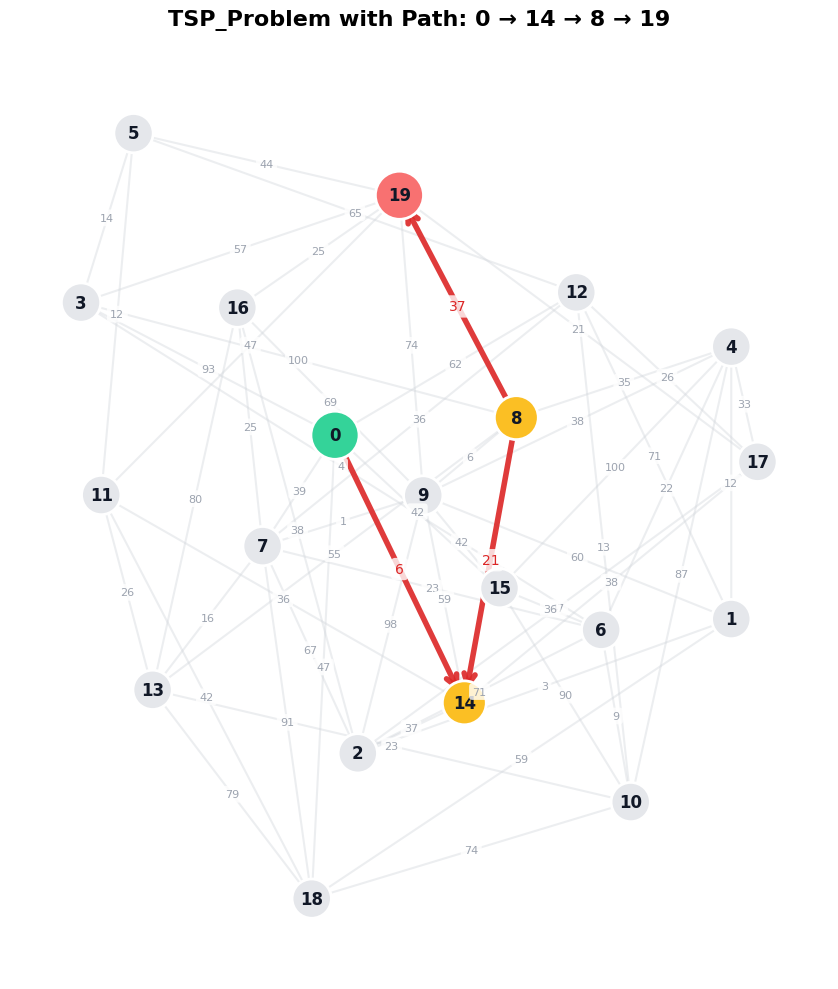


📍 Path Details:
  Step  1: Node 0 → Node 14  (weight:    6.0)
  Step  2: Node 14 → Node 8  (weight:   21.0)
  Step  3: Node 8 → Node 19  (weight:   37.0)
  Total Path Weight: 64.0
  Nodes Visited: 4
  Edges Traversed: 3



In [12]:
plot_graph_with_path(example_graph, shortest_path)

<a id='4-1'></a>

### Test Exercise 1

In [13]:
unittests.test_find_shortest_path(find_shortest_path)

 All tests passed!
  If you made your solution in a different cell, make sure to include it in the graded cell as well.


**Congratulations on completing Exercise 1!**

You've built the shortest path finder for TravelOptima's platform.

---

## Continue with Exercise 2 (GRADED)

Now let's tackle the tour optimization problem!

---

<a id='ex02'></a>

<a id='ex02'></a>
### Exercise 2

**From Sarah:** *"Now for the tour optimizer! We need an algorithm that finds a good tour visiting all the selected countries. It doesn't have to be perfect - just efficient enough for our customers!"*

---

**Your Task:** Find a good tour visiting all chosen countries.

**The Challenge:**

Unlike Exercise 1 (shortest path between two points), this is the **Traveling Salesman Problem (TSP)** - find a short route that visits all locations and returns to start.

This is a famous problem in computer science! Finding the absolute best solution takes too long for many countries, so we'll use a **greedy algorithm** called **Nearest Neighbor** to find a good solution quickly.

**Function Signature:**
```python
def optimize_world_tour(graph_json, start_node):
    """
    Returns: list of nodes representing the tour (including return to start)
    Example: [0, 1, 2, 11, 12, 9, ..., 0]
    """
```

**Requirements:**
- Visit all countries exactly once
- Return to start (must be included in the returned list)
- Use the Nearest Neighbor algorithm
- Return tour as list of node numbers

---

**The Nearest Neighbor Algorithm:**

This greedy algorithm is simple and effective:

1. Start at the start_node
2. While there are unvisited countries:
   - Go to the nearest unvisited country
   - Mark it as visited
3. Return to start_node to complete the tour

**Example prompt for your LLM:**

```
I need to implement the Nearest Neighbor algorithm for the Traveling Salesman Problem in Python.

Here's what I need:
1. A function that takes a graph (with nodes and weighted edges) and a start node
2. Build the tour by always going to the nearest unvisited neighbor
3. Return the complete tour including return to start

The graph format is:
{
    "nodes": [0, 1, 2, 3, 4],
    "edges": [
        {"from": 0, "to": 1, "weight": 10},
        {"from": 1, "to": 3, "weight": 12},
        ...
    ],
    "directed": False
}

Can you help me implement this? I should NOT import any new libraries.
```

**Hints:**
- Build an adjacency dictionary to look up distances quickly
- Keep track of which nodes you've visited
- The tour should start and end with start_node
- No new library imports!

---

#### Load World Tour Data

The dataset includes countries from around the world with flight connections.

In [27]:
# Load the world tour graph with countries from around the globe
world_tour_graph, country_info = load_world_tour_graph('data/world_tour_countries.csv')

print("🌍 World Tour TSP_Problem Loaded!")
print(f"Countries available: {len(world_tour_graph['nodes'])}")
print(f"Total routes: {len(world_tour_graph['edges'])}")
print()
print("Sample countries (showing first 15):")
for node_id in sorted(list(country_info.keys())[:15]):
    info = country_info[node_id]
    print(f"  Node {node_id:2d}: {info['name']:20s} ({info['code']})")

if len(country_info) > 15:
    print(f"  ... and {len(country_info) - 15} more countries")

🌍 World Tour TSP_Problem Loaded!
Countries available: 15
Total routes: 105

Sample countries (showing first 15):
  Node  0: Canada               (CA)
  Node  1: United States        (US)
  Node  2: Mexico               (MX)
  Node  3: Guatemala            (GT)
  Node  4: Costa Rica           (CR)
  Node  5: Panama               (PA)
  Node  6: Colombia             (CO)
  Node  7: Venezuela            (VE)
  Node  8: Brazil               (BR)
  Node  9: Peru                 (PE)
  Node 10: Chile                (CL)
  Node 11: Argentina            (AR)
  Node 12: Cuba                 (CU)
  Node 13: Jamaica              (JM)
  Node 14: Trinidad and Tobago  (TT)


#### Helper Function

The `calculate_tour_distance()` function is imported from utils.

In [ ]:
# Helper function calculate_tour_distance() is now imported from utils
# It calculates the total distance of a tour including return to start

<a id='4-2'></a>

#### Implement Your Solution

**Implementation Steps:**

1. **Extract graph data** - Get nodes, edges, and whether graph is directed
2. **Build adjacency dictionary** - For fast distance lookups between any two nodes
3. **Initialize tour** - Start with `[start_node]`
4. **Apply Nearest Neighbor:**
   - Keep a set of unvisited nodes
   - At each step, find the closest unvisited neighbor
   - Add it to the tour and mark as visited
   - Repeat until all nodes are visited
5. **Close the tour** - Add start_node at the end

**Tips:**
- Use a dictionary of dictionaries for adjacency: `adjacency[from_node][to_node] = weight`
- For undirected graphs, add edges in both directions
- Use `min()` with a key function to find the nearest neighbor
- Test incrementally - print the tour to verify it visits all nodes

**No new library imports!** Use only what's already imported.

In [30]:
def optimize_world_tour(graph_json, start_node):
    """
    Returns a tour using the Nearest Neighbor algorithm.

    Parameters:
    - graph_json (dict): Graph in JSON format with 'nodes', 'edges', and optional 'directed' fields
    - start_node: The node where the tour starts and ends

    Returns:
    - list: A list of nodes representing the tour, including the return to start.
            Example: [0, 1, 2, 11, 12, 9, ..., 0]
            Returns [] if a complete tour cannot be formed.
    """
    nodes = graph_json.get("nodes", [])
    edges = graph_json.get("edges", [])
    directed = graph_json.get("directed", False)

    # Start node must exist
    if start_node not in nodes:
        return []

    # Special case: empty graph
    if not nodes:
        return []

    # Special case: only one node
    if len(nodes) == 1:
        return [start_node, start_node]

    # Build adjacency dictionary for quick weight lookup
    # graph[u][v] = weight
    graph = {}
    for node in nodes:
        graph[node] = {}

    for edge in edges:
        u = edge["from"]
        v = edge["to"]
        w = edge["weight"]

        graph[u][v] = w

        if not directed:
            graph[v][u] = w

    visited = set()
    visited.add(start_node)

    tour = [start_node]
    current_node = start_node

    # Visit all other nodes using nearest neighbor
    while len(visited) < len(nodes):
        nearest_node = None
        nearest_weight = float("inf")

        # Check all unvisited neighbors of current_node
        for neighbor in graph[current_node]:
            if neighbor not in visited:
                weight = graph[current_node][neighbor]
                if weight < nearest_weight:
                    nearest_weight = weight
                    nearest_node = neighbor

        # If no reachable unvisited neighbor exists, tour cannot be completed
        if nearest_node is None:
            return []

        tour.append(nearest_node)
        visited.add(nearest_node)
        current_node = nearest_node

    # Must return to start to complete the tour
    if start_node not in graph[current_node]:
        return []

    tour.append(start_node)
    return tour

<a id='4-2-test'></a>

### Test Exercise 2

In [31]:
unittests.test_optimize_world_tour(optimize_world_tour)

 All tests passed!
  If you made your solution in a different cell, make sure to include it in the graded cell as well.


#### Visualize Your Tour

In [32]:
# Visualize the tour on a world map
your_tour = optimize_world_tour(world_tour_graph, 0)
country_coords = create_country_coords_for_plot()
plot_continent_path(your_tour, coords=country_coords, title="My World Tour", scope="world")

#### Congratulations!

You've completed Exercise 2!

**What you learned:**
- The famous Traveling Salesman Problem (TSP)
- Greedy algorithms (Nearest Neighbor)
- When "good enough" solutions are better than perfect ones
- How to work with graph data structures efficiently

---

---

## Interactive Widget: Tour & Flight Finder

Launch the web application to test your algorithms with real data!

The widget lets you:
1. **Point-to-Point:** Find cheapest flight route between two countries (Exercise 1)
2. **Multi-Stop Tour:** Plan optimal tour visiting any countries you choose (Exercise 2)

Pick countries from around the world and see your algorithm in action!


In [ ]:
# Launch the interactive widget (opens in a browser window)
# Two modes:
# 1. Point-to-Point: Find cheapest route between two countries
# 2. Multi-Stop Tour: Plan a tour visiting multiple countries worldwide

launch_tour_widget(optimize_world_tour, find_shortest_path)

# Note: The old inline widget is still available if needed:
# create_americas_tour_widget(optimize_world_tour)


🌍 World Tour & Flight Finder Widget

✓ Server starting at http://localhost:5000/
✓ Browser will open automatically...

📊 Flight Network Statistics:
   • 37 countries
   • 117 flight routes
   • 17.6% network density
   • $395.09 average flight price

📝 Two Modes Available:
   1. SHORTEST PATH: Find cheapest route between two countries
   2. TSP TOUR: Find optimal tour visiting multiple countries

⚠️  To stop the server: Click the stop button (■) in the notebook toolbar

 * Serving Flask app 'tour_widget_server'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


---

<a id='ex03'></a>

<a id='ex03'></a>
### Exercise 3

**From Sarah:** *"Great work on the algorithms! If you want to personalize the app, feel free to customize the UI. Make it your own - change colors, add features, translate it... whatever you like!"*

---

**This exercise is OPTIONAL and NOT GRADED. Have fun with it!**

**Your Mission:** Customize the web application to make it uniquely yours!

### What You Can Customize

| Category | Examples | Difficulty |
|----------|----------|------------|
| **Colors** | Dark mode, school colors, ocean theme | Easy |
| **Text** | Translate to Spanish/French, rename buttons | Easy |
| **Features** | More route options, export button | Medium |
| **Map** | Different colors, larger markers, projections | Medium |
| **Layout** | Button sizes, spacing, mobile-friendly | Medium |

### How to Customize (No HTML/CSS Knowledge Needed!)

**The Secret:** Everything is controlled by ONE file: `static/widget_config.js`

**Steps:**
1. **Open** `static/widget_config.js` in a text editor
2. **Copy** the entire file (select all and copy)
3. **Paste** to ChatGPT or Claude
4. **Ask** for your customization (see examples below)
5. **Copy** the improved config back
6. **Paste** into `static/widget_config.js` and save
7. **Restart** the Flask server (see below)
8. **Refresh** your browser to see changes!

### Example Customization Requests

Try asking your LLM:

**Easy:**
```
"Change the color scheme to ocean blue: primary #0066cc, secondary #0099ff"

"Translate all text to Spanish (keep technical terms like TSP in English)"

"Show 8 alternative routes instead of 4"
```

**Medium:**
```
"Add dark mode toggle. Use background #1a1a1a and text #e0e0e0 for dark theme"

"Make it mobile-friendly: taller buttons (50px), larger text, more spacing"

"Change flight paths to green (#00cc00) and make markers purple (#9933ff)"
```

**Advanced:**
```
"Enable dark mode, purple theme (#9966ff), 6 routes, export button, 50px buttons"
```

---

### How to Restart the Flask Server

After editing `static/widget_config.js`, you need to restart the server to see changes.

**Method 1: Stop and Re-run (Recommended)**
1. Go to the cell above where you ran `launch_tour_widget(...)`
2. Click in the cell output area
3. Click the Stop button (■) in the toolbar
4. Re-run the cell 
5. Browser will open with your changes!

**Method 2: Interrupt Kernel**
1. Click the Stop button (■) in the toolbar
2. Re-run the `launch_tour_widget(...)` cell

**Method 3: Use Helper Function (Below)**
Run the cell below to restart automatically.

---


In [39]:
# HELPER: Quick Restart Function
# Run this cell after editing widget_config.js to see your changes

import os
import signal
import time
import socket

def restart_widget():
    """
    Restart the Flask widget server to apply config changes.
    
    Usage:
    1. Edit static/widget_config.js
    2. Save the file
    3. Run this cell
    4. Widget will restart with your changes!
    """
    print("🔄 Restarting widget server...\n")
    
    # Try to find and kill existing Flask process using Python
    try:
        import psutil
        killed = False
        for proc in psutil.process_iter(['pid', 'name', 'connections']):
            try:
                # Check if process has connection on port 5000
                for conn in proc.connections():
                    if conn.laddr.port == 5000:
                        print(f"✓ Found process {proc.pid} using port 5000, terminating...")
                        proc.terminate()
                        proc.wait(timeout=3)
                        killed = True
                        break
            except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.TimeoutExpired):
                continue
        
        if killed:
            time.sleep(1)
            print("✓ Stopped existing server")
        else:
            print("✓ No existing server found")
    except ImportError:
        # psutil not available, try basic socket check
        print("⚠️  psutil not available, checking port...")
        try:
            sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
            result = sock.connect_ex(('127.0.0.1', 5000))
            sock.close()
            if result == 0:
                print("⚠️  Port 5000 is in use. Please manually stop the server.")
                print("    Click the Stop button (■) in the toolbar")
                return
            else:
                print("✓ Port 5000 is free")
        except:
            pass
    
    # Launch widget again
    print("✓ Launching widget with updated configuration...\n")
    launch_tour_widget(optimize_world_tour, find_shortest_path)

# Uncomment the line below and run this cell to restart:
# restart_widget()

### Customization Examples

Here are some ready-to-use examples. Copy the config file and ask your LLM:

#### Example 1: Dark Mode
```
"In this widget configuration, enable dark mode by default and add a toggle button.

Dark mode colors:
- Background: #1a1a1a
- Text: #e0e0e0
- Primary: #8b9dc3

[PASTE YOUR CONFIG HERE]"
```

#### Example 2: School/Company Colors
```
"Change the color scheme to:
- Primary: #003366 (navy blue)
- Secondary: #FFD700 (gold)
- Accent: #CC0000 (red)

[PASTE YOUR CONFIG HERE]"
```

#### Example 3: Spanish Translation
```
"Translate all text in this config to Spanish.
Keep technical terms like 'TSP' and 'API' in English.

[PASTE YOUR CONFIG HERE]"
```

#### Example 4: More Features
```
"Update this config to:
1. Show 8 alternative routes instead of 4
2. Enable the export button
3. Make buttons taller (50px)
4. Show distance and price for all routes

[PASTE YOUR CONFIG HERE]"
```

---


### Understanding `widget_config.js`

The config file has 6 main sections:

```javascript
const WIDGET_CONFIG = {
    // 1. THEME: Colors and visual appearance
    theme: {
        primaryColor: '#667eea',
        backgroundColor: '#ffffff',
        darkMode: { enabled: false, ... }
    },
    
    // 2. FEATURES: Enable/disable functionality
    features: {
        alternativeRoutes: 4,        // How many routes to show
        enableDarkModeToggle: false, // Show dark mode button
        enableExportButton: false    // Show export button
    },
    
    // 3. TEXT: All labels and messages
    text: {
        pageTitle: 'World Tour & Flight Finder',
        findPathButton: 'Find Cheapest Route',
        // ... 30+ more text strings
    },
    
    // 4. MAP: Plotly visualization settings
    map: {
        pathColor: 'red',
        markerSize: 10,
        projection: 'natural earth'
    },
    
    // 5. LAYOUT: Sizing and spacing
    layout: {
        buttonHeight: '45px',
        sidebarWidth: '400px'
    },
    
    // 6. ADVANCED: Power user settings
    advanced: {
        debugMode: false  // Set true to see config in browser console
    }
};
```

**Key Points:**
- Each section is independent - change one without affecting others
- The file is heavily commented - read the comments for guidance
- Set `debugMode: true` to see what's happening in browser console (browser developer tools)

---


### Troubleshooting

#### Changes Don't Appear?
1. Did you save `static/widget_config.js`?
2. Did you restart the Flask server?
3. Did you refresh the browser ?
4. Check browser console (browser developer tools → Console) for errors

#### Widget Won't Load?
1. Make sure only ONE Flask server is running (use the restart_widget() helper function above)
2. Check that port 5000 is available
3. Try restarting the Jupyter kernel

#### Config File Breaks?
1. Check for syntax errors (missing commas, quotes, brackets)
2. Use a JSON/JavaScript validator online
3. Restore from backup if needed: `cp static/widget_config_backup.js static/widget_config.js`

#### Best Practices
1. **Make one change at a time** - easier to debug
2. **Keep a backup** - copy config before major changes
3. **Test incrementally** - verify each change works
4. **Enable debug mode** - set `debugMode: true` to see what's happening
5. **Ask your LLM** - if something breaks, paste the error message!

---

### Congratulations!

You've completed all exercises!

**What you've learned:**
- Graph algorithms (Dijkstra, TSP heuristics)
- Working with LLMs as coding assistants
- Algorithm optimization and trade-offs
- Testing and debugging
- Web application basics (if you did Exercise 3)

**Next steps:**
1. Make sure Exercises 1 & 2 are complete (GRADED)
2. Submit to Coursera
3. Customize the widget if you want!